# Post processing and visualizing mandyoc data

The following notebook allows the user to reproduce Figures 6 and 7.

In [1]:
#increase the display size to 95% of window width
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
display(HTML("<style>.output_result { max-width:95% !important; }</style>"))


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import glob
import os
import sys
import pylab as pl
import xarray as xr
import pymp
import mpl_toolkits.axisartist
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
import string
local_path = os.getcwd()

sys.path.insert(0, f"{local_path}/functions")

from mandyocIO import read_datasets, change_dataset, plot_property, find_nearest, plot_tracked_particles, plot_ptt_paths

# How to plot

## In the following cell, you must inform:
 - Which Figure you wish to plot by comment/uncomment the `fig_to_plot` options

In [60]:
# fig_to_plot = 'Fig6'
fig_to_plot = 'Fig7'

#Set scenario path
scenarios_path = local_path.split('/')
scenarios_path = f"{'/'.join(scenarios_path[:-1])}/scenarios"


if(fig_to_plot=='Fig6'):
    scenarios = [
            f"{scenarios_path}/1w_Ho35W1",
            f"{scenarios_path}/1s_Ho35S1",
            f"{scenarios_path}/2w_He35W1",
            f"{scenarios_path}/2s_He35S1",
            f"{scenarios_path}/3w_Ho40W1",
            f"{scenarios_path}/3s_Ho40S1",

            ]
    time_crustal_breakbups = [26.00,
                              17.67,
                              28.40,
                              20.00,
                              33.19,
                              25.00]
    

    time_lithospheric_breakbups = [12.85, # this is for complete breakup
                                   24.78,
                                   12.82,
                                   26.28,
                                   15.99,
                                   36.87]
    v = 1
    print(f"Plotting scenarios with v = {v} cm/yr: 1w, 1s, 2w, 2s, 3w, 3s")

if(fig_to_plot=='Fig7'):
    scenarios = [
                f"{scenarios_path}/4w_Ho35W2",
                f"{scenarios_path}/4s_Ho35S2",
                f"{scenarios_path}/5w_He35W2",
                f"{scenarios_path}/5s_He35S2",
                f"{scenarios_path}/6w_Ho40W2",
                f"{scenarios_path}/6s_Ho40S2",
                ]
    
    time_crustal_breakbups = [12.91,
                              10.74,
                              12.12,
                              9.18,
                              16.70,
                              11.68]
        
    time_lithospheric_breakbups = [5.50,
                                   8.98,
                                   6.06,
                                   9.64,
                                   6.00,
                                   12.26]
    v = 2
    print(f"Plotting scenarios with v = {v} cm/yr: 4w, 4s, 5w, 5s, 6w, 6s")

#Reading datasets from tracked particles
trackdataset0 = xr.open_dataset(f"{scenarios[0]}/_track_xzPT_all_steps.nc")
trackdataset1 = xr.open_dataset(f"{scenarios[1]}/_track_xzPT_all_steps.nc")
trackdataset2 = xr.open_dataset(f"{scenarios[2]}/_track_xzPT_all_steps.nc")
trackdataset3 = xr.open_dataset(f"{scenarios[3]}/_track_xzPT_all_steps.nc")
trackdataset4 = xr.open_dataset(f"{scenarios[4]}/_track_xzPT_all_steps.nc")
trackdataset5 = xr.open_dataset(f"{scenarios[5]}/_track_xzPT_all_steps.nc")

Plotting scenarios with v = 2 cm/yr: 4w, 4s, 5w, 5s, 6w, 6s


Saving Fig7.jpeg


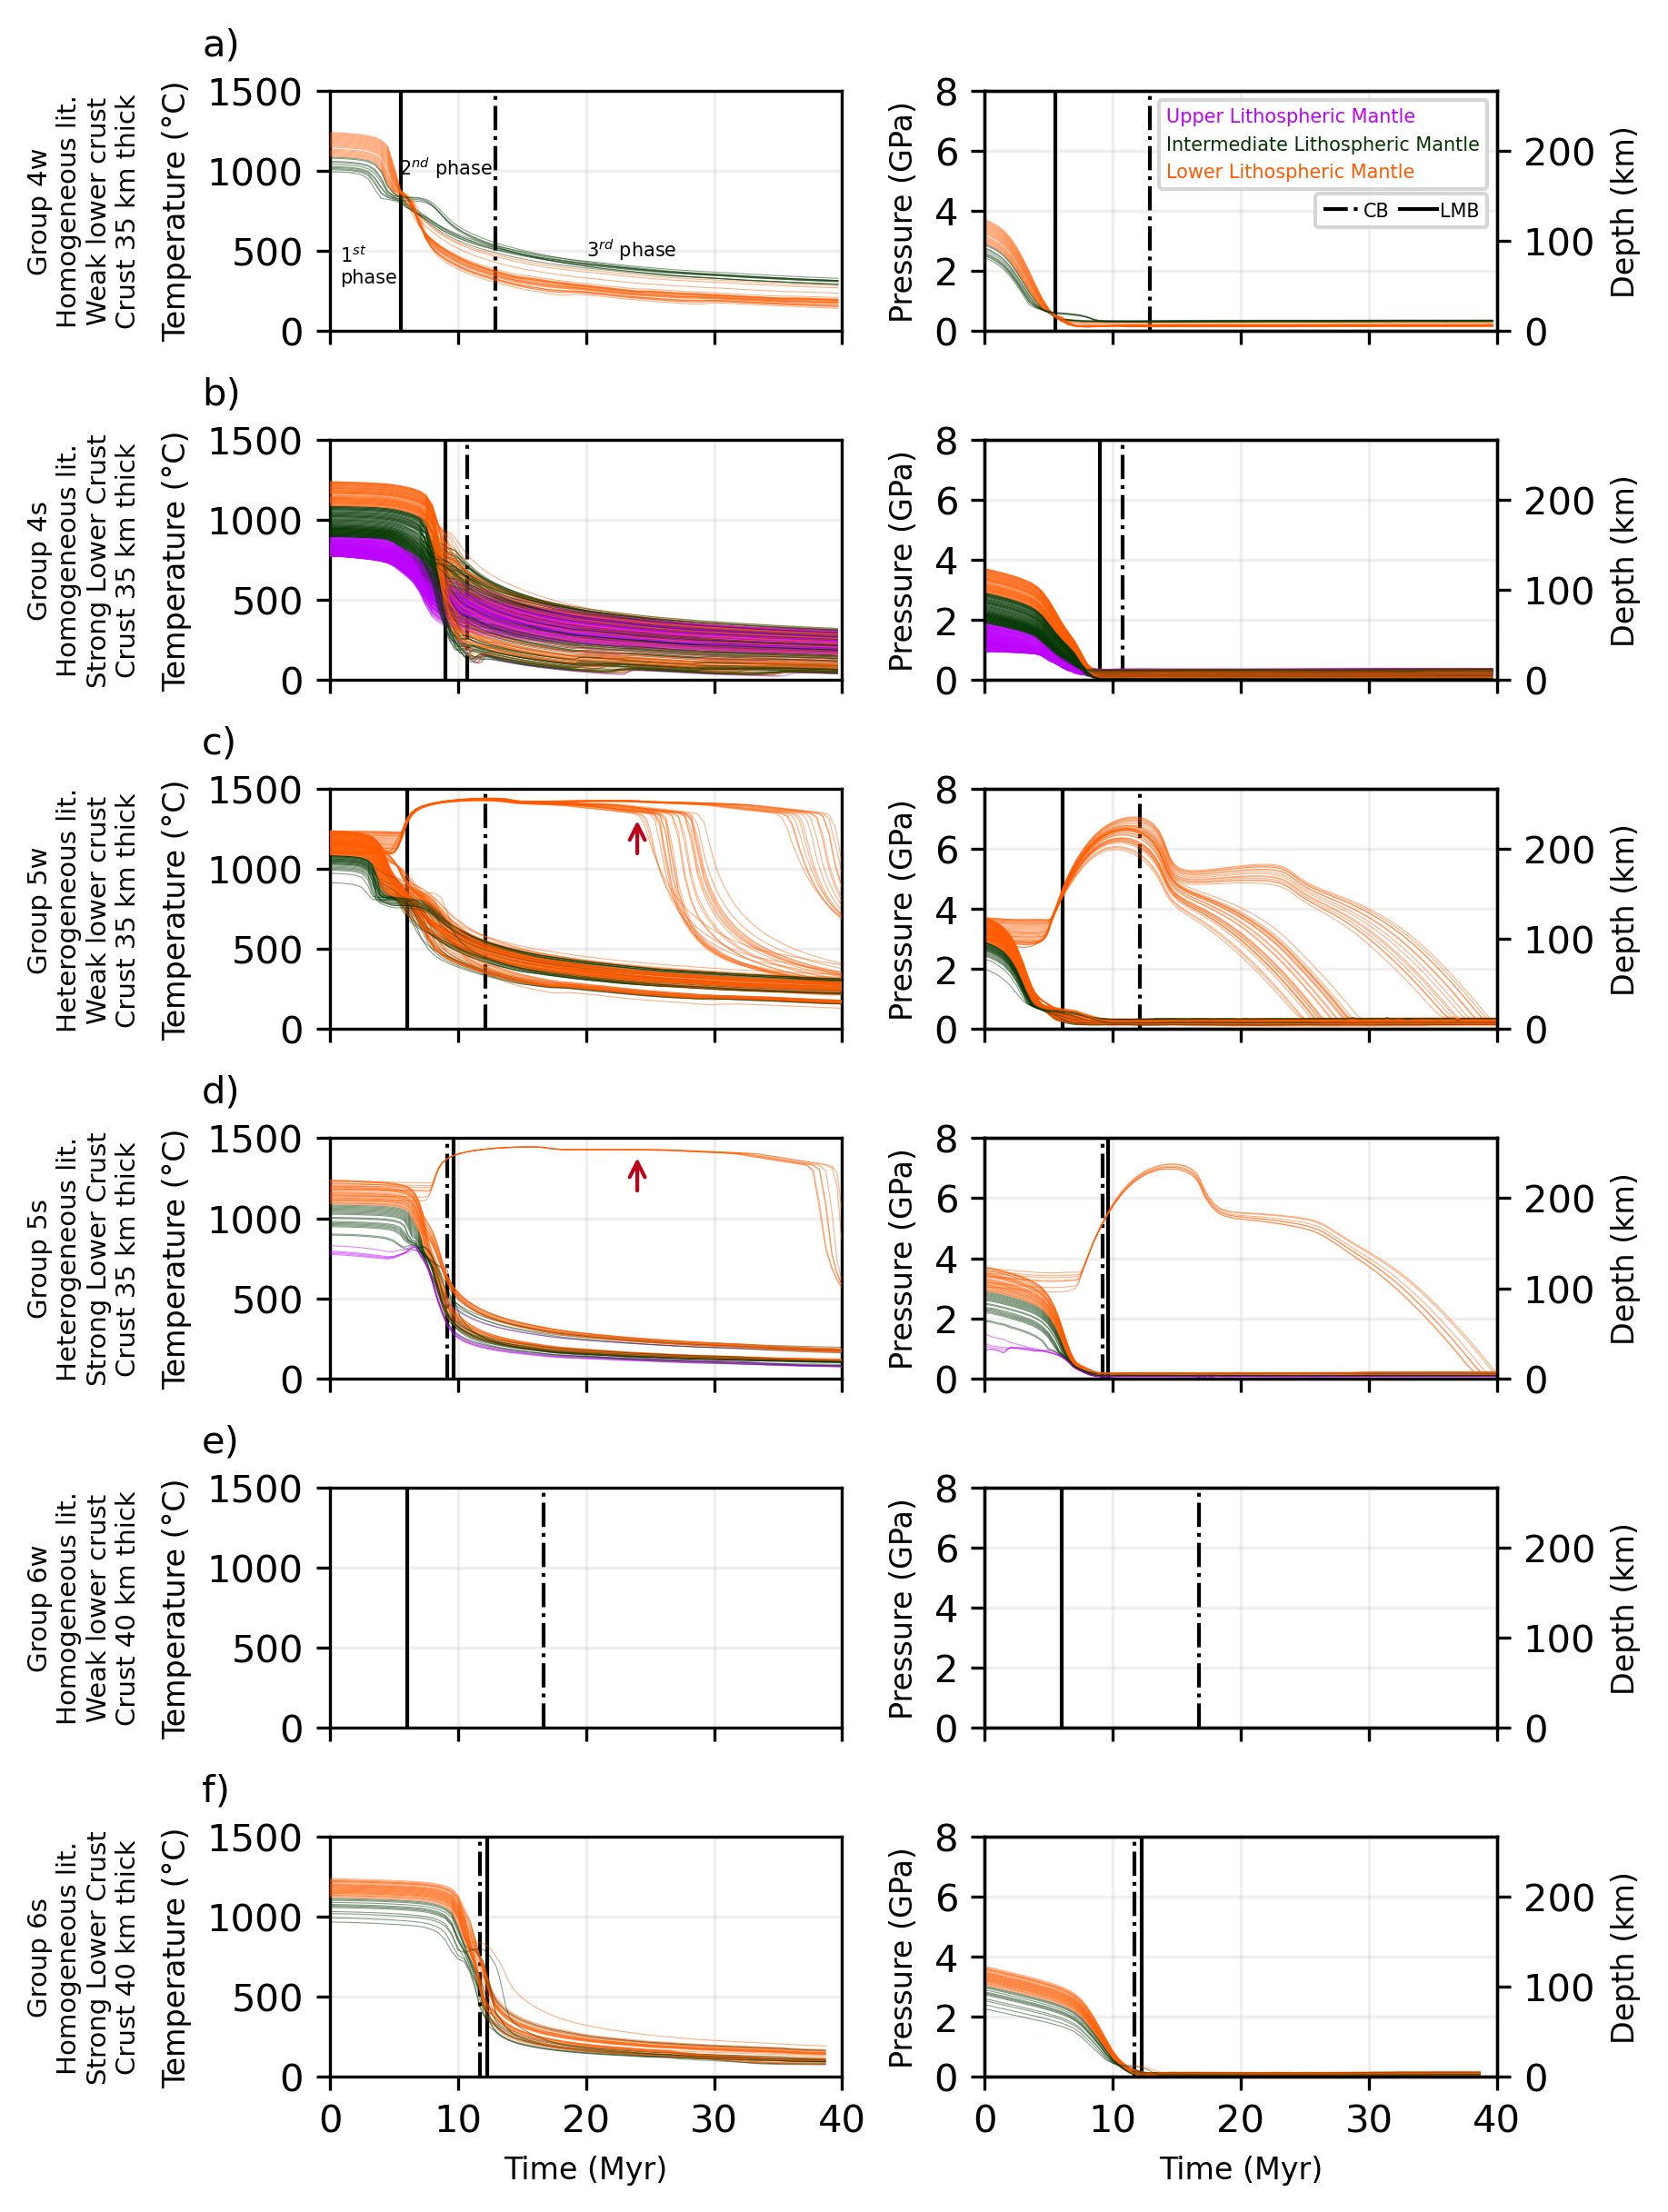

In [61]:
def take_three_particles(layer_codes, particles_layers, T_initial):
    '''
    This function takes three particles from the set of Lagrangean particles.

    Parameters:
    -----------
    layer_codes : list of int
        List of codes of the layers to consider. According to Mandyoc scenario.
    particles_layers : numpy.array
        Array with the layer codes of Lagrangean particles according to Mandyoc scenario.
    T_initial : numpy.array
        Array with the initial temperature of the Lagrangean particles.

    Returns:
    --------
    cond2plot : numpy.array
        Boolean array with the condition to plot the three particles.
    cond : numpy.array
        Boolean array with the condition to select the particles of the layer(s) of interest.
    Ti_layer_max : float
        Initial temperature of the particle with the maximum initial temperature in the layer(s) of interest.
    Ti_layer_mid : float
        Initial temperature of the particle with the median initial temperature in the layer(s) of interest.
    Ti_layer_min : float
        Initial temperature of the particle with the minimum initial temperature in the layer(s) of interest.
    len(particles_layer) : int
        Number of particles in the layer(s) of interest.
    '''

    if(len(layer_codes) == 1):
        cond = particles_layers == layer_codes[0]
    else:
        cond = (particles_layers == layer_codes[0]) | (particles_layers == layer_codes[1])

    particles_layer = particles_layers[cond]
    
    T_initial_layer = T_initial[cond] #initial temperature of lithospheric mantle particles

    T_initial_layer_sorted = np.sort(T_initial_layer)

    Ti_layer_max = np.max(T_initial_layer_sorted)
    mid_index = len(T_initial_layer_sorted)//2
    Ti_layer_mid = T_initial_layer_sorted[mid_index]
    Ti_layer_min = np.min(T_initial_layer_sorted)

    cond2plot = (T_initial == Ti_layer_min) | (T_initial == Ti_layer_mid) | (T_initial == Ti_layer_max)

    return cond2plot, cond, Ti_layer_max, Ti_layer_mid, Ti_layer_min, len(particles_layer)

def plot_PT_evolution(axT, axP, time, P, T, color='xkcd:light gray', linewidth=1, markersize=2, alpha=1.0, zorder=60, plot_each_5Myr=True, marker='.'):
    '''
    This function plots the PTt path of a particle in the PT diagram.

    Parameters:
    -----------
    axT : matplotlib.axes.Axes
        Axes object for the temperature plot.
    axP : matplotlib.axes.Axes
        Axes object for the pressure plot.
    time : numpy.array
        Array with the time values.
    P : numpy.array
        Array with the pressure values.
    T : numpy.array
        Array with the temperature values.
    color : str
        Color of the plot.
    linewidth : float
        Width of the plot line.
    markersize : float
        Size of the markers.
    alpha : float
        Transparency of the plot.
    zorder : int
        Order of the plot in the z-axis.
    plot_each_5Myr : bool
        Whether to plot markers every 5 Myr.
    marker : str
        Marker style.

    Returns:
    --------
    None
    '''
    axT.plot(time, T[::, particle], '-', color=color, linewidth=linewidth, alpha=alpha, zorder=zorder) #PTt path
    axP.plot(time, P[::, particle], '-', color=color, linewidth=linewidth, alpha=alpha, zorder=zorder) #PTt path

    if(plot_each_5Myr == True):
        for j in np.arange(0, time[-1], 2):
            idx = find_nearest(time, j)
            axT.plot(time[idx], T[idx, particle], marker, color=color, markersize=markersize, zorder=zorder)
            axP.plot(time[idx], P[idx, particle], marker, color=color, markersize=markersize, zorder=zorder)

def plot_arrow(ax, x_start, y_start, x_end, y_end, color='xkcd:black', linewidth=1.0, zorder=62):
    '''
    This function plots an arrow in the given axes.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        Axes object to plot the arrow.
    x_start : float
        x coordinate of the start of the arrow in axes coordinates (0 to 1).
    y_start : float
        y coordinate of the start of the arrow in axes coordinates (0 to 1).
    x_end : float
        x coordinate of the end of the arrow in axes coordinates (0 to 1).
    y_end : float
        y coordinate of the end of the arrow in axes coordinates (0 to 1).
    color : str
        Color of the arrow.
    linewidth : float
        Width of the arrow line.
    zorder : int
        Order of the arrow in the z-axis.
    '''
    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start), xycoords=ax.transAxes,
    arrowprops=dict(arrowstyle='->', color=color, linewidth=linewidth), zorder=zorder)

trackdatasets = [trackdataset0, trackdataset1, trackdataset2, trackdataset3, trackdataset4, trackdataset5]#, trackdataset6, trackdataset7]

asthenosphere_code = 0 #asthenosphere
mantle_lithosphere1_code = 1
mantle_lithosphere2_code = 3 #lithospheric mantle
lower_crust_code = 4 #lower crust
upper_crust_code = 5 #upper crust

linewidth = 0.85
markersize = 3.5
color_lower_crust='xkcd:brown'
color_mlit_upper='xkcd:bright purple'#'xkcd:cerulean blue'
color_mlit_intermediate='xkcd:dark green'#'xkcd:scarlet'
color_mlit_lower='xkcd:bright orange'#'xkcd:dark green'

fig, axs = plt.subplots(6, 2 , figsize=(6, 8), dpi=300, constrained_layout=True, sharex=True)
axs = axs.flatten()
ylims = np.array([0, 8]) #for pressure plots
ylims_temperature = np.array([0, 1500]) #for temperature plots
xlims = np.array([0, 40]) if fig_to_plot=='Fig6' else np.array([0, 40])
plot_each_5Myr = False

for trackdataset, tc, tl, i in zip(trackdatasets, time_crustal_breakbups, time_lithospheric_breakbups, range(len(trackdatasets))):
    x_track = trackdataset.xtrack.values[::-1]
    z_track = trackdataset.ztrack.values[::-1]
    P = trackdataset.ptrack.values[::-1]
    T = trackdataset.ttrack.values[::-1]
    time = trackdataset.time.values[::-1]
    steps = trackdataset.step.values[::-1]
    n = int(trackdataset.ntracked.values)
    nTotal = np.size(x_track)
    steps = nTotal//n #number of steps

    x_track = np.reshape(x_track,(steps,n))
    z_track = np.reshape(z_track,(steps,n))
    P = np.reshape(P,(steps,n))
    T = np.reshape(T,(steps,n))
    particles_layers = trackdataset.particles_layers.values[::-1] #code of the tracked layer

    T_initial = T[0] #initial temperature of particles
    P_initial = P[0] #initial pressure of particles
    z_initial = z_track[0]

    h_air = 40.0e3 #m
    h_lithosphere = 120.0e3 #m
    #thickness of mantle lithosphere sections
    thickness_upper = 30.0e3
    thickness_intermediate = 30.0e3

    hcrust = 40.0e3 if ((i == 4) or (i == 5)) else 35.0e3 #m. Crustal thickness
    thickness_lower = h_lithosphere - (hcrust + thickness_upper + thickness_intermediate)

    zb_crust_and_air = -1.0 * (hcrust + h_air) #m z depth of the bottom of the crust considering air layer
    zb_upper = zb_crust_and_air - thickness_upper #m. The values of z_initial are negative, so we need to subtract
    zb_intermediate = zb_upper - thickness_intermediate #m. The values of z_initial are negative, so we need to subtract
    zb_lower = -1.0 * (h_lithosphere + h_air) #m z depth of the bottom of the lithosphere considering air layer

    if(asthenosphere_code in particles_layers):
        cond_upper_2plot_ast = (P_initial <= 4000) & (z_initial < zb_crust_and_air) & (z_initial >= zb_upper) #condition for upper particles - the values of z_initial are negative, so the logical condition is inverted
        cond_intermediate_2plot_ast = (P_initial <= 4000) & (z_initial < zb_upper) & (z_initial >= zb_intermediate) #condition for intermediate particles
        cond_lower_2plot_ast = (P_initial <= 4000) & (z_initial < zb_intermediate) & (z_initial >= zb_lower) #condition for lower particles
        plot_asthenosphere_particles = True
        
    else:
        plot_asthenosphere_particles = False
        cond_ast2plot = np.arange(0, n, 1) == np.arange(0, n, 1) + 1

    if((mantle_lithosphere1_code in particles_layers) | (mantle_lithosphere2_code in particles_layers)):
        cond_upper_2plot_mlit = (z_initial < zb_crust_and_air) & (z_initial >= zb_upper) #condition for upper particles - the values of z_initial are negative, so the logical condition is inverted
        cond_intermediate_2plot_mlit = (z_initial < zb_upper) & (z_initial >= zb_intermediate) #condition for intermediate particles
        cond_lower_2plot_mlit = (z_initial < zb_intermediate) & (z_initial >= zb_lower) #condition for lower particles

        plot_mantle_lithosphere_particles = True
    else:
        plot_mantle_lithosphere_particles = False
        cond_mantle_lithosphere2plot = np.arange(0, n, 1) == np.arange(0, n, 1) + 1

    if(lower_crust_code in particles_layers):
        cond_lower_crust2plot, cond_lower_crust, Ti_crust_max, Ti_crust_mid, Ti_crust_min, n_lower_crust = take_three_particles([lower_crust_code], particles_layers, T_initial)

        dict_lower_crust_markers = {Ti_crust_max: '*',
                                    Ti_crust_mid: '^',
                                    Ti_crust_min: 'D'}

        plot_lower_crust_particles = False

    else:
        plot_lower_crust_particles = False
        cond_lower_crust2plot = np.arange(0, n, 1) == np.arange(0,n,1) + 1

    plot_other_particles = True #plot particles that are not in the other categories

    linewidth = 0.25
    for particle, particle_layer in zip(range(n), particles_layers):
                #Plot particles in prop subplot
        if((plot_lower_crust_particles == True) & (particle_layer == lower_crust_code)):
            if(cond_lower_crust2plot[particle] == True):
                marker = dict_lower_crust_markers[T_initial[particle]]
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_lower_crust, linewidth=linewidth, markersize=markersize, zorder=61, plot_each_5Myr=plot_each_5Myr, marker='.')

        if((plot_mantle_lithosphere_particles == True) & ((particle_layer == mantle_lithosphere1_code) | (particle_layer == mantle_lithosphere2_code))):
            if(cond_upper_2plot_mlit[particle] == True):
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_mlit_upper, linewidth=linewidth, markersize=markersize, alpha=0.5, zorder=60, plot_each_5Myr=plot_each_5Myr)
            if(cond_intermediate_2plot_mlit[particle] == True):
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_mlit_intermediate, linewidth=linewidth, markersize=markersize, alpha=0.5, zorder=60, plot_each_5Myr=plot_each_5Myr)
            if(cond_lower_2plot_mlit[particle] == True):
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_mlit_lower, linewidth=linewidth, markersize=markersize, alpha=0.5, zorder=60, plot_each_5Myr=plot_each_5Myr)

        if((plot_asthenosphere_particles == True) & (particle_layer == asthenosphere_code)):
            if(cond_upper_2plot_ast[particle] == True):
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_mlit_upper, linewidth=linewidth, markersize=markersize, alpha=0.5, zorder=60, plot_each_5Myr=plot_each_5Myr)
            if(cond_intermediate_2plot_ast[particle] == True):
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_mlit_intermediate, linewidth=linewidth, markersize=markersize, alpha=0.5, zorder=60, plot_each_5Myr=plot_each_5Myr)
            if(cond_lower_2plot_ast[particle] == True):
                plot_PT_evolution(axs[2*i], axs[2*i+1], time, P/1.0e3, T, color=color_mlit_lower, linewidth=linewidth, markersize=markersize, alpha=0.5, zorder=60, plot_each_5Myr=plot_each_5Myr)

    axs[2*i].plot([tc, tc], ylims_temperature, '-.', color='xkcd:black', linewidth=1, zorder=59) #crustal breakup time
    axs[2*i].plot([tl, tl], ylims_temperature, '-', color='xkcd:black', linewidth=1, zorder=59) #lithospheric breakup time
    # axs[2*i].text(tc/xlims[-1]-0.01, 1.03, 'CB', transform=axs[2*i].transAxes, color='xkcd:black', fontsize=8, rotation=45)
    # axs[2*i].text(tl/xlims[-1]+0.01, 1.03, 'LMB', transform=axs[2*i].transAxes, color='xkcd:black', fontsize=8, rotation=45)

    axs[2*i+1].plot([tc, tc], ylims, '-.', color='xkcd:black', linewidth=1, zorder=59) #crustal breakup time
    axs[2*i+1].plot([tl, tl], ylims, '-', color='xkcd:black', linewidth=1, zorder=59) #lithospheric breakup time
    # axs[2*i+1].text(tc/xlims[-1]-0.01, 1.03, 'CB', transform=axs[2*i+1].transAxes, color='xkcd:black', fontsize=8, rotation=45)
    # axs[2*i+1].text(tl/xlims[-1]+0.01, 1.03, 'LMB', transform=axs[2*i+1].transAxes, color='xkcd:black', fontsize=8, rotation=45)


# axs[0][0].grid('-k', alpha=0.2)

for ax, number in zip(axs, range(len(axs))):
    ax.grid('-k', alpha=0.2)
    # ax.text(-0.2, 1.1, f"{string.ascii_lowercase[number]})", transform=ax.transAxes, fontsize=12)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims_temperature) if ax.get_subplotspec().is_first_col() else ax.set_ylim(ylims)
    ax.set_xlabel('Time (Myr)', fontsize=8) if  ax.get_subplotspec().is_last_row() else ax.set_xlabel('')
    ax.set_ylabel('Temperature (°C)', fontsize=8) if ax.get_subplotspec().is_first_col() else ax.set_ylabel('Pressure (GPa)', fontsize=8)

    if ax.get_subplotspec().is_last_col():

        #Dealing with pressure y-axis
        ax.set_yticks(np.linspace(0, ylims[-1], 5))

        #Dealing with depth secondary y-axis
        ax1 = ax.twinx()
        ax1.set_ylim(1000*ylims/30)
        # ax1.tick_params(axis='y', labelright=False, labelleft=True, labelsize=fsize)
        ax1.set_ylabel('Depth (km)', fontsize=8)
        ax1.tick_params(axis='y')

#creating legends
axs = axs.flatten()

idx_legend = 1
ax2 = axs[idx_legend].twinx()
ax2.axis('off')
# ax2.plot([-10,-10], [-10,-10], '-', color=color_lower_crust, markersize=5, label='Lower Crust')
ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_upper, markersize=5, label='Upper Lithospheric Mantle')
ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_intermediate, markersize=5, label='Intermediate Lithospheric Mantle')
ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_lower, markersize=5, label='Lower Lithospheric Mantle')
ax2.legend(loc='upper right', ncol=1, fontsize=5, handlelength=0, handletextpad=0, labelcolor='linecolor')

idx_legend2 = 1
ax3 = axs[idx_legend2].twinx()
ax3.axis('off')
ax3.plot([-10,-10], [-10,-10], '-.', color='xkcd:black', linewidth=1, label='CB')
ax3.plot([-10,-10], [-10,-10], '-', color='xkcd:black', linewidth=1, label='LMB')
ax3.legend(loc='center right', ncol=2, fontsize=5, columnspacing=0.5, handlelength=2, handletextpad=0.15, labelcolor='linecolor')

xpos = -0.48
ypos = 0.5
fsize = 7

if(fig_to_plot=='Fig6'):
    agroup = f"Group 1w"
    bgroup = f"Group 1s"
    cgroup = f"Group 2w"
    dgroup = f"Group 2s"
    egroup = f"Group 3w"
    fgroup = f"Group 3s"
if(fig_to_plot=='Fig7'):
    agroup = f"Group 4w"
    bgroup = f"Group 4s"
    cgroup = f"Group 5w"
    dgroup = f"Group 5s"
    egroup = f"Group 6w"
    fgroup = f"Group 6s"

axs[0].text(xpos, ypos, f"{agroup}\nHomogeneous lit.\nWeak lower crust\nCrust 35 km thick", transform=axs[0].transAxes, fontsize=fsize, rotation=90, ha='center', va='center')
axs[2].text(xpos, ypos, f"{bgroup}\nHomogeneous lit.\nStrong Lower Crust\nCrust 35 km thick", transform=axs[2].transAxes, fontsize=fsize, rotation=90, ha='center', va='center')
axs[4].text(xpos, ypos, f"{cgroup}\nHeterogeneous lit.\nWeak lower crust\nCrust 35 km thick", transform=axs[4].transAxes, fontsize=fsize, rotation=90, ha='center', va='center')
axs[6].text(xpos, ypos, f"{dgroup}\nHeterogeneous lit.\nStrong Lower Crust\nCrust 35 km thick", transform=axs[6].transAxes, fontsize=fsize, rotation=90, ha='center', va='center')
axs[8].text(xpos, ypos, f"{egroup}\nHomogeneous lit.\nWeak lower crust\nCrust 40 km thick", transform=axs[8].transAxes, fontsize=fsize, rotation=90, ha='center', va='center')
axs[10].text(xpos, ypos, f"{fgroup}\nHomogeneous lit.\nStrong Lower Crust\nCrust 40 km thick", transform=axs[10].transAxes, fontsize=fsize, rotation=90, ha='center', va='center')

xpos = -0.25
ypos = 1.15
axs[0].text(xpos, ypos, 'a)', transform=axs[0].transAxes, fontsize=10)
axs[2].text(xpos, ypos, 'b)', transform=axs[2].transAxes, fontsize=10)
axs[4].text(xpos, ypos, 'c)', transform=axs[4].transAxes, fontsize=10)
axs[6].text(xpos, ypos, 'd)', transform=axs[6].transAxes, fontsize=10)
axs[8].text(xpos, ypos, 'e)', transform=axs[8].transAxes, fontsize=10)
axs[10].text(xpos, ypos, 'f)', transform=axs[10].transAxes, fontsize=10)

#Writting the exhumation phases
if(fig_to_plot=='Fig6'):
    phase1 = f"1$^{{st}}$ phase:\nAdiabatic\nexhumation"
    xpos1 = 0.05
    ypos1 = 0.2
    axs[0].text(xpos1, ypos1, phase1, transform=axs[0].transAxes, fontsize=5, color='xkcd:black', rotation=0)

    phase2 = f"2$^{{nd}}$ phase:\nCooling and\ndecompression"
    xpos2 = 0.35
    ypos2 = 0.65
    axs[0].text(xpos2, ypos2, phase2, transform=axs[0].transAxes, fontsize=5, color='xkcd:black', rotation=0)

    phase3 = f"3$^{{rd}}$ phase:\nAsymptotic\ncooling"
    xpos3 = 0.73
    ypos3 = 0.3
    axs[0].text(xpos3, ypos3, phase3, transform=axs[0].transAxes, fontsize=5, color='xkcd:black', rotation=0)

    #Indicating the migration of deformation focus effects in the second phase and wandering particles
    color_wandering = 'xkcd:scarlet'
    #a)
    plot_arrow(axs[0],
               x_start = 0.5,
               y_start = 0.6,
               x_end = 0.4,
               y_end = 0.55)
    #b)
    plot_arrow(axs[2],
               x_start = 0.6,
               y_start = 0.65,
               x_end = 0.5,
               y_end = 0.6)
    #c)
    plot_arrow(axs[4],
               x_start = 0.5,
               y_start = 0.65,
               x_end = 0.4,
               y_end = 0.6)

    plot_arrow(axs[4],
               x_start = 0.6,
               y_start = 0.7,
               x_end = 0.6,
               y_end = 0.9,
               color=color_wandering)
    #d)
    plot_arrow(axs[6],
               x_start = 0.65,
               y_start = 0.65,
               x_end = 0.55,
               y_end = 0.6)

    plot_arrow(axs[6],
               x_start = 0.6,
               y_start = 0.75,
               x_end = 0.6,
               y_end = 0.95,
               color=color_wandering)
    #e)
    plot_arrow(axs[8],
               x_start = 0.6,
               y_start = 0.65,
               x_end = 0.5,
               y_end = 0.6)

    #f)
    plot_arrow(axs[10],
               x_start = 0.83,
               y_start = 0.67,
               x_end = 0.73,
               y_end = 0.62)

if(fig_to_plot=='Fig7'):
    phase1 = f"1$^{{st}}$\nphase"
    xpos1 = 0.02
    ypos1 = 0.2
    axs[0].text(xpos1, ypos1, phase1, transform=axs[0].transAxes, fontsize=5, color='xkcd:black', rotation=0)

    phase2 = f"2$^{{nd}}$ phase"
    xpos2 = 0.135
    ypos2 = 0.65
    axs[0].text(xpos2, ypos2, phase2, transform=axs[0].transAxes, fontsize=5, color='xkcd:black', rotation=0)

    phase3 = f"3$^{{rd}}$ phase"
    xpos3 = 0.5
    ypos3 = 0.31
    axs[0].text(xpos3, ypos3, phase3, transform=axs[0].transAxes, fontsize=5, color='xkcd:black', rotation=0)

    #c)
    plot_arrow(axs[4],
               x_start = 0.6,
               y_start = 0.7,
               x_end = 0.6,
               y_end = 0.9,
               color=color_wandering)
    #d)
    plot_arrow(axs[6],
               x_start = 0.6,
               y_start = 0.75,
               x_end = 0.6,
               y_end = 0.95,
               color=color_wandering)


figname = fig_to_plot
fig_format = 'jpeg'
print(f"Saving {fig_to_plot}.{fig_format}")

fig.savefig(f"figures/{fig_to_plot}.{fig_format}", dpi=300)